# Analysis - Priority Banding Simulations

In [1]:
import pandas as pd
import pickle
import json
import os
import datetime as dt
from matplotlib import pyplot as plt
import re
import numpy as np
import seaborn as sns

# Load Data

In [2]:
banding_out = "D:/lco/custom_scheduler/output_files/banding"
banding_in = "D:/lco/custom_scheduler/input_files/banding"
baseline_out = "D:/lco/custom_scheduler/output_files/baseline"
baseline_in = "D:/lco/custom_scheduler/input_files/baseline"
print(os.path.isdir(banding_out))
print(os.path.isdir(banding_in))
print(os.path.isdir(baseline_out))
print(os.path.isdir(baseline_in))

True
True
True
True


## Calibration Proposals

In [3]:
calib_proposals = [
    "OGG_calib",
    "MuSCAT Commissioning",
    "auto_focus",
    "LCOEngineering",
    "COJ_calib",
    "FLOYDS standards",
    "Photometric standards",
    "standard"
]

## Filemap

In [4]:
filemap = {}
for dirname, folders, filenames in os.walk(baseline_out):
    for filename in filenames:
        if "_perfect" in filename:
            continue
        output_filepath = os.path.join(baseline_out, filename)
        forename, ext = os.path.splitext(filename)
        banding_forename = forename.replace("baseline", "pb")
        normal = banding_forename + "_30-20-10" + ext
        scaled = banding_forename + "_100-55-10" + ext
        exponential = banding_forename + "_100-30-10" + ext

        filemap[forename] = {
            "baseline": os.path.join(baseline_out, filename),
            "normal": os.path.join(banding_out, normal),
            "scaled": os.path.join(banding_out, scaled),
            "exponential": os.path.join(banding_out, exponential),
            "input_baseline": os.path.join(baseline_in, filename),
            "input_normal": os.path.join(banding_in, normal),
            "input_scaled": os.path.join(banding_in, scaled),
            "input_exponential": os.path.join(banding_in, exponential)
        }

for filename in filemap:
    print(filename)
    for key, value in filemap[filename].items():
        print(key, os.path.isfile(value))
    print()

baseline_2020-08
baseline True
normal True
scaled True
exponential True
input_baseline True
input_normal True
input_scaled True
input_exponential True

baseline_2021-02
baseline True
normal True
scaled True
exponential True
input_baseline True
input_normal True
input_scaled True
input_exponential True

baseline_2021-08
baseline True
normal True
scaled True
exponential True
input_baseline True
input_normal True
input_scaled True
input_exponential True

baseline_2022-02
baseline True
normal True
scaled True
exponential True
input_baseline True
input_normal True
input_scaled True
input_exponential True



## Load All

In [5]:
def get_visible_duration(windows):
    total_time = dt.timedelta()
    for site_code, intervals in windows.items():
        interval_time = intervals.get_total_time()
        if interval_time != 0:
            total_time += interval_time
    return total_time.total_seconds()

def set_duration_category(total_duration):
    if total_duration <= 600:
        return "0_Short"
    elif total_duration <= 1800:
        return "1_Medium"
    else:
        return "2_Long"

In [6]:
datasets = []

for filename in filemap:
    o_base = pickle.load(open(filemap[filename]["baseline"], "rb"))["final_completed_requests"].keys()
    o_normal = pickle.load(open(filemap[filename]["normal"], "rb"))["final_completed_requests"].keys()
    o_scaled = pickle.load(open(filemap[filename]["scaled"], "rb"))["final_completed_requests"].keys()
    o_exp = pickle.load(open(filemap[filename]["exponential"], "rb"))["final_completed_requests"].keys()

    i_base = pickle.load(open(filemap[filename]["input_baseline"], "rb"))
    i_normal = pickle.load(open(filemap[filename]["input_normal"], "rb"))
    i_scaled = pickle.load(open(filemap[filename]["input_scaled"], "rb"))
    i_exp = pickle.load(open(filemap[filename]["input_exponential"], "rb"))

    p_base = i_base["proposals"]
    p_normal = i_normal["proposals"]
    p_scaled = i_scaled["proposals"]
    p_exp = i_exp["proposals"]

    requests = i_base["all_requests"]

    requests = requests[~requests["proposal_id"].isin(calib_proposals)]
    
    requests["b_scheduled"] = requests["id"].isin(o_base)
    requests["n_scheduled"] = requests["id"].isin(o_normal)
    requests["s_scheduled"] = requests["id"].isin(o_scaled)
    requests["e_scheduled"] = requests["id"].isin(o_exp)

    requests["b_priority"] = requests["proposal_id"].map(p_base)
    requests["n_priority"] = requests["proposal_id"].map(p_normal)
    requests["s_priority"] = requests["proposal_id"].map(p_scaled)
    requests["e_priority"] = requests["proposal_id"].map(p_exp)

    requests["visible_time"] = requests["windows"].apply(get_visible_duration)
    requests["flexibility"] = requests["visible_time"] / requests["total_duration"]
    requests["duration_category"] = requests["total_duration"].apply(set_duration_category)
    requests["priority_category"] = requests["n_priority"].map({10: "Low", 20: "Intermediate", 30: "High"})

    df = requests[["id", "total_duration", "duration_category", "b_scheduled", "n_scheduled", "s_scheduled", "e_scheduled",
                   "b_priority", "priority_category"]]

    df["filename"] = filename
    
    datasets.append(df)

df = pd.concat(datasets)

C:\Users\Foggy\AppData\Local\Temp\ipykernel_10548\272727915.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  requests["b_scheduled"] = requests["id"].isin(o_base)
C:\Users\Foggy\AppData\Local\Temp\ipykernel_10548\272727915.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  requests["n_scheduled"] = requests["id"].isin(o_normal)
C:\Users\Foggy\AppData\Local\Temp\ipykernel_10548\272727915.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

In [7]:
df

,id,total_duration,duration_category,b_scheduled,n_scheduled,s_scheduled,e_scheduled,b_priority,priority_category,filename
2373081,2373081,3088,2_Long,False,False,False,False,16,Low,baseline_2020-08
2373019,2373019,19422,2_Long,True,True,True,True,30,High,baseline_2020-08
2373018,2373018,3388,2_Long,False,False,False,False,16,Low,baseline_2020-08
2373014,2373014,3388,2_Long,False,False,False,False,16,Low,baseline_2020-08
2372981,2372981,499,0_Short,False,False,False,False,20,Low,baseline_2020-08
...,...,...,...,...,...,...,...,...,...,...
2858916,2858916,360,0_Short,False,False,False,False,20,Low,baseline_2022-02
2858847,2858847,2445,2_Long,True,True,True,True,35,High,baseline_2022-02
2858588,2858588,2745,2_Long,True,True,True,True,35,High,baseline_2022-02
2858587,2858587,1480,1_Medium,False,False,False,False,20,Low,baseline_2022-02


In [8]:
df["scaled_positive"] = (df["n_scheduled"]==False) & (df["s_scheduled"]==True)
df["scaled_negative"] = (df["n_scheduled"]==True) & (df["s_scheduled"]==False)
df["scaled_change"] = df["s_scheduled"].astype(int) - df["n_scheduled"].astype(int)
df["exp_positive"] = (df["n_scheduled"]==False) & (df["e_scheduled"]==True)
df["exp_negative"] = (df["n_scheduled"]==True) & (df["e_scheduled"]==False)
df["exp_change"] = df["e_scheduled"].astype(int) - df["n_scheduled"].astype(int)

In [9]:
l = []
for priority, group in df.groupby("priority_category"):
    l.append((priority, "normal", group["n_scheduled"].sum()))
    l.append((priority, "scaled", group["s_scheduled"].sum()))
    l.append((priority, "exponential", group["e_scheduled"].sum()))
pd.DataFrame(l).pivot(index=0, columns=1, values=2).loc[["High", "Intermediate", "Low"], ["normal", "scaled", "exponential"]]

1,normal,scaled,exponential
0,,,
High,14378,14709,14967
Intermediate,3407,3426,3328
Low,5416,5408,5618


### By Semester

In [10]:
# for semester, g1 in df.groupby("filename"):
#     l = []
#     for priority, g2 in g1.groupby("priority_category"):
#         subset_count = len(g2)
#         b_count = g2["b_scheduled"].sum()
#         n_count = g2["n_scheduled"].sum()
#         s_count = g2["s_scheduled"].sum()
#         e_count = g2["e_scheduled"].sum()
#         s_diff = s_count - n_count
#         e_diff = e_count - n_count
#         s_normed = s_diff / subset_count
#         e_normed = e_diff / subset_count

#         l.append([priority, b_count/subset_count, n_count/subset_count, s_count/subset_count, e_count/subset_count])

        
#         # l.append((priority, "normal", g2["n_scheduled"].sum(), len(g2)))
#         # l.append((priority, "scaled", g2["s_scheduled"].sum(), len(g2)))
#         # l.append((priority, "exponential", g2["e_scheduled"].sum(), len(g2)))
#     a = pd.DataFrame(l, columns=["priority", "baseline", "linear", "scaled", "exponential"])
#     b = a.set_index("priority").loc[["High", "Medium", "Low"], :]
#     sns.heatmap(b)
#     plt.show()
    
#     # sem_df = pd.DataFrame(l).pivot(index=0, columns=1, values=2).loc[["High", "Medium", "Low"], ["normal", "scaled", "exponential"]]
#     # c = sem_df.div(sem_df.sum(axis=1), axis=0)
#     # sns.heatmap(sem_df)
#     # plt.show()
#     # break

In [11]:
# for semester, g1 in df.groupby("filename"):
#     l = []
#     for priority, g2 in g1.groupby("priority_category"):
#         subset_count = len(g2)
#         b_count = g2["b_scheduled"].sum()
#         n_count = g2["n_scheduled"].sum()
#         s_count = g2["s_scheduled"].sum()
#         e_count = g2["e_scheduled"].sum()
#         s_diff = s_count - n_count
#         e_diff = e_count - n_count
#         s_normed = s_diff / subset_count
#         e_normed = e_diff / subset_count

#         l.append([priority, s_normed, e_normed])

        
#         # l.append((priority, "normal", g2["n_scheduled"].sum(), len(g2)))
#         # l.append((priority, "scaled", g2["s_scheduled"].sum(), len(g2)))
#         # l.append((priority, "exponential", g2["e_scheduled"].sum(), len(g2)))
#     a = pd.DataFrame(l, columns=["priority", "scaled", "exponential"])
#     b = a.set_index("priority").loc[["High", "Medium", "Low"], :]
#     sns.heatmap(b, annot=True)
#     plt.show()
    
#     # sem_df = pd.DataFrame(l).pivot(index=0, columns=1, values=2).loc[["High", "Medium", "Low"], ["normal", "scaled", "exponential"]]
#     # c = sem_df.div(sem_df.sum(axis=1), axis=0)
#     # sns.heatmap(sem_df)
#     # plt.show()
#     # break

# THESE ONES

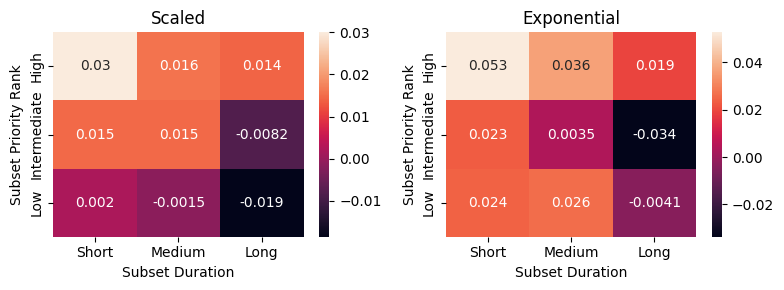

In [12]:
ls = []
le = []
for (priority, duration), g2 in df.groupby(["priority_category", "duration_category"]):
    subset_count = len(g2)
    b_count = g2["b_scheduled"].sum()
    n_count = g2["n_scheduled"].sum()
    s_count = g2["s_scheduled"].sum()
    e_count = g2["e_scheduled"].sum()
    s_diff = s_count - n_count
    e_diff = e_count - n_count
    s_normed = s_diff / subset_count
    e_normed = e_diff / subset_count

    ls.append([priority, duration, s_normed])
    le.append([priority, duration, e_normed]) 
    
    # l.append((priority, "normal", g2["n_scheduled"].sum(), len(g2)))
    # l.append((priority, "scaled", g2["s_scheduled"].sum(), len(g2)))
    # l.append((priority, "exponential", g2["e_scheduled"].sum(), len(g2)))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes = axes.flatten()

ax=axes[0]
a_s = pd.DataFrame(ls, columns=["priority", "duration", "scaled"])
b_s = a_s.pivot(index="priority", columns="duration", values="scaled").loc[["High", "Intermediate", "Low"], :]
b_s.rename(columns={"0_Short": "Short", "1_Medium": "Medium", "2_Long": "Long"}, inplace=True)
sns.heatmap(b_s, annot=True, ax=axes[0])
ax.set_title("Scaled")
ax.set_xlabel("Subset Duration")
ax.set_ylabel("Subset Priority Rank")

# print("All", "Exponential")
ax = axes[1]
a_e = pd.DataFrame(le, columns=["priority", "duration", "exponential"])
b_e = a_e.pivot(index="priority", columns="duration", values="exponential").loc[["High", "Intermediate", "Low"], :]
b_e.rename(columns={"0_Short": "Short", "1_Medium": "Medium", "2_Long": "Long"}, inplace=True)
sns.heatmap(b_e, annot=True, ax=axes[1])
ax.set_title("Exponential")
ax.set_xlabel("Subset Duration")
ax.set_ylabel("Subset Priority Rank")

plt.tight_layout()
plt.savefig("plots/priority_banding_all.pdf", format="pdf")
plt.show()

2020-08
2021-02
2021-08
2022-02


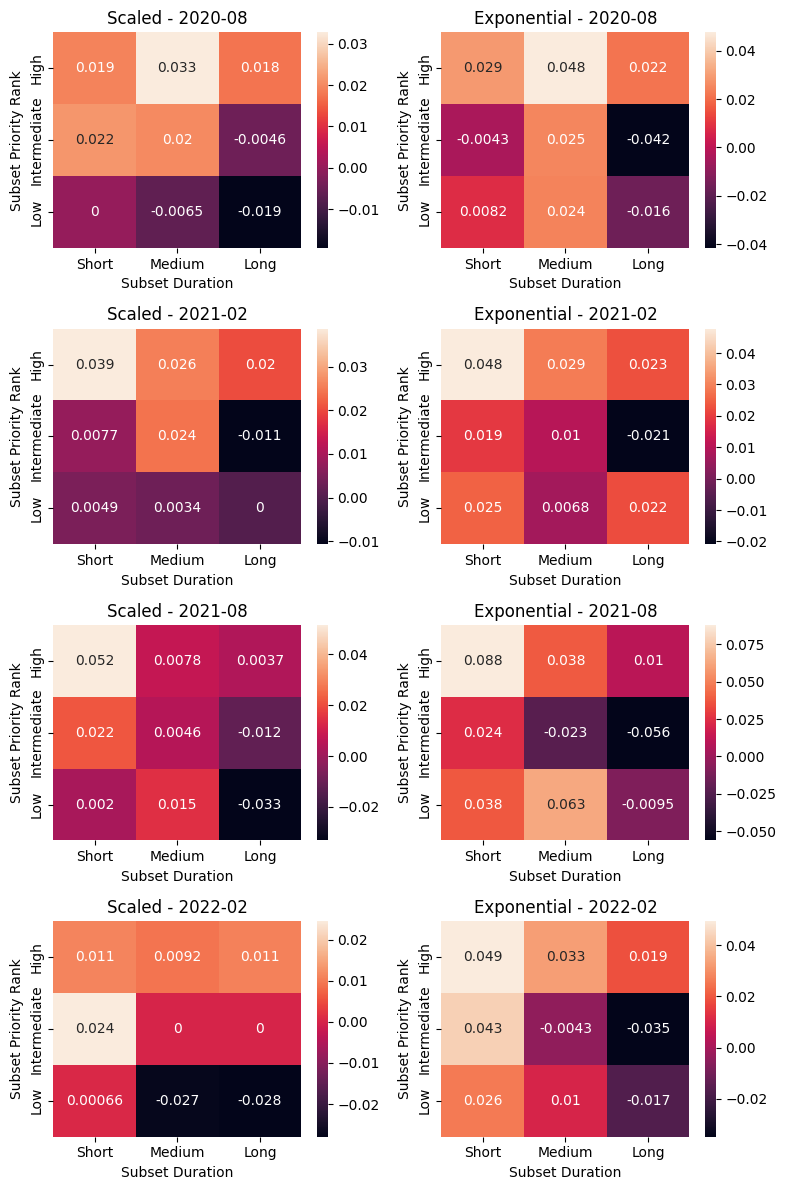

In [13]:
fig = plt.figure(figsize=(8, 12))
fig_count = 0

for semester, g1 in df.groupby("filename"):
    ls = []
    le = []
    for (priority, duration), g2 in g1.groupby(["priority_category", "duration_category"]):
        subset_count = len(g2)
        b_count = g2["b_scheduled"].sum()
        n_count = g2["n_scheduled"].sum()
        s_count = g2["s_scheduled"].sum()
        e_count = g2["e_scheduled"].sum()
        s_diff = s_count - n_count
        e_diff = e_count - n_count
        s_normed = s_diff / subset_count
        e_normed = e_diff / subset_count
    
        ls.append([priority, duration, s_normed])
        le.append([priority, duration, e_normed]) 
        
        # l.append((priority, "normal", g2["n_scheduled"].sum(), len(g2)))
        # l.append((priority, "scaled", g2["s_scheduled"].sum(), len(g2)))
        # l.append((priority, "exponential", g2["e_scheduled"].sum(), len(g2)))

    fig_count += 1
    ax = fig.add_subplot(4, 2, fig_count)
    
    print(semester.split("_")[1])
    a_s = pd.DataFrame(ls, columns=["priority", "duration", "scaled"])
    b_s = a_s.pivot(index="priority", columns="duration", values="scaled").loc[["High", "Intermediate", "Low"], :]
    b_s.rename(columns={"0_Short": "Short", "1_Medium": "Medium", "2_Long": "Long"}, inplace=True)
    sns.heatmap(b_s, annot=True, ax=ax)
    ax.set_title(f"Scaled - {semester.split('_')[1]}")
    ax.set_xlabel("Subset Duration")
    ax.set_ylabel("Subset Priority Rank")

    fig_count += 1
    ax = fig.add_subplot(4, 2, fig_count)
    
    # print("All", "Exponential")
    a_e = pd.DataFrame(le, columns=["priority", "duration", "exponential"])
    b_e = a_e.pivot(index="priority", columns="duration", values="exponential").loc[["High", "Intermediate", "Low"], :]
    b_e.rename(columns={"0_Short": "Short", "1_Medium": "Medium", "2_Long": "Long"}, inplace=True)
    sns.heatmap(b_e, annot=True, ax=ax)
    ax.set_title(f"Exponential - {semester.split('_')[1]}")
    ax.set_xlabel("Subset Duration")
    ax.set_ylabel("Subset Priority Rank")
    
plt.tight_layout()
plt.savefig("plots/priority_banding_by_semester.pdf", format="pdf")
plt.show()

## Unsure how to make this work

In [14]:
# df.columns

In [15]:
# df["duration_category"].value_counts()

In [16]:
# df["priority_numeric"] = df["priority_category"].map({"Low": 1, "Medium": 2, "High": 3})
# df["duration_numeric"] = df["duration_category"].map({"0_Short": 1, "1_Medium": 2, "2_Long": 3})

# for duration, group in df.groupby("duration_category"):
    

# X = df[["priority_numeric"]]
# X = sm.add_constant(X)
# y = df["scaled_positive"].astype(int)
# model = sm.Logit(y, X)
# result = model.fit()
# print(result.summary())

# # for (priority, duration), g2 in df.groupby(["priority_category", "duration_category"]):
# #     X = g2[[, "e_scheduled"]].astype(int)
# #     X = sm.add_constant(X)
# #     y = g2["n_scheduled"].astype(int)
# #     model = sm.Logit(y, X)
# #     result = model.fit()
# #     print(result.summary())
    

In [17]:
# X = df[["priority_numeric"]]
# X = sm.add_constant(X)
# y = df["exp_positive"].astype(int)
# model = sm.Logit(y, X)
# result = model.fit()
# print(result.summary())

In [18]:
# for duration, group in df.groupby("duration_category"):
#     print(duration)
#     X = group[["priority_numeric"]]
#     X = sm.add_constant(X)
#     y = group["scaled_positive"].astype(int)
#     model = sm.Logit(y, X)
#     result = model.fit()
#     print(result.summary())

# # for (priority, duration), g2 in df.groupby(["priority_category", "duration_category"]):
# #     X = g2[[, "e_scheduled"]].astype(int)
# #     X = sm.add_constant(X)
# #     y = g2["n_scheduled"].astype(int)
# #     model = sm.Logit(y, X)
# #     result = model.fit()
# #     print(result.summary())
    

In [19]:
# for duration, group in df.groupby("duration_category"):
#     print(duration)
#     X = group[["priority_numeric"]]
#     X = sm.add_constant(X)
#     y = group["exp_positive"].astype(int)
#     model = sm.Logit(y, X)
#     result = model.fit()
#     print(result.summary())

# # for (priority, duration), g2 in df.groupby(["priority_category", "duration_category"]):
# #     X = g2[[, "e_scheduled"]].astype(int)
# #     X = sm.add_constant(X)
# #     y = g2["n_scheduled"].astype(int)
# #     model = sm.Logit(y, X)
# #     result = model.fit()
# #     print(result.summary())
    

In [20]:
# import pandas as pd
# import statsmodels.api as sm

# # Assuming df is your DataFrame
# df['priority_numeric'] = df['priority_category'].map({'Low': 1, 'Medium': 2, 'High': 3})

# # Define the independent variables (e.g., Priority, Condition_1, Condition_2, Condition_3)
# X = df[['priority_numeric', 'n_scheduled', 's_scheduled', 'e_scheduled']].astype(int)
# X = sm.add_constant(X)

# # Define the dependent variable (control scheduling outcome)
# y = df['b_scheduled'].astype(int)

# # Fit logistic regression
# model = sm.Logit(y, X)
# result = model.fit()

# # View summary of the model
# print(result.summary())

In [21]:
#     contingency_table = pd.crosstab(group["new_window_length"], group["change_negative"])
#     chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# ls = []
# le = []
# for (priority, duration), g2 in df.groupby(["priority_category", "duration_category"]):
#     subset_count = len(g2)
#     n_count = g2["n_scheduled"].sum()
#     s_count = g2["s_scheduled"].sum()
#     e_count = g2["e_scheduled"].sum()
#     s_diff = s_count - n_count
#     e_diff = e_count - n_count
#     s_normed = s_diff / subset_count
#     e_normed = e_diff / subset_count




    

#     ls.append([priority, duration, s_normed])
#     le.append([priority, duration, e_normed]) 

# fig, axes = plt.subplots(1, 2, figsize=(8, 3))
# axes = axes.flatten()

# print(semester.split("_")[1])
# ax=axes[0]
# a_s = pd.DataFrame(ls, columns=["priority", "duration", "scaled"])
# b_s = a_s.pivot(index="priority", columns="duration", values="scaled").loc[["High", "Medium", "Low"], :]
# b_s.rename(columns={"0_Short": "Short", "1_Medium": "Medium", "2_Long": "Long"}, inplace=True)
# sns.heatmap(b_s, annot=True, ax=axes[0])
# ax.set_title("Scaled")
# # plt.show()

# # print("All", "Exponential")
# ax = axes[1]
# a_e = pd.DataFrame(le, columns=["priority", "duration", "exponential"])
# b_e = a_e.pivot(index="priority", columns="duration", values="exponential").loc[["High", "Medium", "Low"], :]
# b_e.rename(columns={"0_Short": "Short", "1_Medium": "Medium", "2_Long": "Long"}, inplace=True)
# sns.heatmap(b_e, annot=True, ax=axes[1])
# ax.set_title("Exponential")

# plt.tight_layout()
# plt.show()

# STOP HERE

In [22]:
# for semester, g1 in df.groupby("filename"):
#     ls = []
#     le = []
#     for (priority, duration), g2 in g1.groupby(["priority_category", "duration_category"]):
#         subset_count = len(g2)
#         b_count = g2["b_scheduled"].sum()
#         n_count = g2["n_scheduled"].sum()
#         s_count = g2["s_scheduled"].sum()
#         e_count = g2["e_scheduled"].sum()
#         s_diff = s_count - n_count
#         e_diff = e_count - n_count
#         s_normed = s_diff / subset_count
#         e_normed = e_diff / subset_count

#         ls.append([priority, duration, s_normed])
#         le.append([priority, duration, e_normed]) 
        
#         # l.append((priority, "normal", g2["n_scheduled"].sum(), len(g2)))
#         # l.append((priority, "scaled", g2["s_scheduled"].sum(), len(g2)))
#         # l.append((priority, "exponential", g2["e_scheduled"].sum(), len(g2)))
#     print(semester, "Scaled")
#     a_s = pd.DataFrame(ls, columns=["priority", "duration", "scaled"])
#     b_s = a_s.pivot(index="priority", columns="duration", values="scaled").loc[["High", "Medium", "Low"], :]
#     sns.heatmap(b_s, annot=True)
#     plt.show()

#     print(semester, "Exponential")
#     a_e = pd.DataFrame(le, columns=["priority", "duration", "exponential"])
#     b_e = a_e.pivot(index="priority", columns="duration", values="exponential").loc[["High", "Medium", "Low"], :]
#     # b_e = a_e.set_index("priority").loc[["High", "Medium", "Low"], :]
#     sns.heatmap(b_e, annot=True)
#     plt.show()
    
#     # sem_df = pd.DataFrame(l).pivot(index=0, columns=1, values=2).loc[["High", "Medium", "Low"], ["normal", "scaled", "exponential"]]
#     # c = sem_df.div(sem_df.sum(axis=1), axis=0)
#     # sns.heatmap(sem_df)
#     # plt.show()
#     # break

In [23]:
# a_s

In [24]:
# a

In [25]:
# for (priority, semester), group in df.groupby(["filename", "priority_category"]):
#     print(priority, semester)
#     print(group["scaled_change"].value_counts(sort=False, ascending=True))
#     print(group["exp_change"].value_counts(sort=False))
#     # print(group[["scaled_change", "exp_change"]].value_counts())
#     print()

In [26]:
# df["scaled_positive"].value_counts()

In [27]:
# df["exp_positive"].value_counts()

# Logistic Regression

In [28]:
# import pandas as pd
# import statsmodels.api as sm

# # Assuming df is your DataFrame
# df['priority_numeric'] = df['priority_category'].map({'Low': 1, 'Medium': 2, 'High': 3})

# # Define the independent variables (e.g., Priority, Condition_1, Condition_2, Condition_3)
# X = df[['priority_numeric', 'n_scheduled', 's_scheduled', 'e_scheduled']].astype(int)
# X = sm.add_constant(X)

# # Define the dependent variable (control scheduling outcome)
# y = df['b_scheduled'].astype(int)

# # Fit logistic regression
# model = sm.Logit(y, X)
# result = model.fit()

# # View summary of the model
# print(result.summary())

In [29]:
# datasets = []

# for filename in filemap:
#     b = pickle.load(open(filemap[filename]["baseline"], "rb"))

# for filename in filemap:
#     i = pickle.load(open(filemap[filename]["input"], "rb")) #input
#     o = pickle.load(open(filemap[filename]["output"], "rb")) #output
#     p = pickle.load(open(filemap[filename]["perfect"], "rb")) #perfect
#     b = pickle.load(open(filemap[filename]["baseline"], "rb")) #baseline

#     proposals = i["proposals"]
#     for calib_name in calib_proposals:
#         if calib_name in proposals:
#             proposals[calib_name] = 0

#     data = i["all_requests"][["id", "proposal_id"]]
#     data["priority"] = data["proposal_id"].apply(lambda x: proposals[x])
#     data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
#     data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
#     data["perfect"] = data["id"].isin(p["scheduled"].keys())
            
#     print("FILENAME:", filename)
#     for priority, group in data.groupby("priority"):
#         print("Priority:", priority)
#         print("Num Requests:", len(group))
#         print("Baseline:", group["baseline"].sum(), f"({round(group['baseline'].sum()/len(group)*100, 2)}%)")
#         print("Scheduled:", group["scheduled"].sum(), f"({round(group['scheduled'].sum()/len(group)*100, 2)}%)")
#         print("Perfect:", group["perfect"].sum(), f"({round(group['perfect'].sum()/len(group)*100, 2)}%)")
#         print()
#     print("===\n\n")

In [30]:
# filemap = {}
# for dirname, folders, filenames in os.walk(banding_in):
#     for filename in filenames:
#         output_filepath = os.path.join(banding_out, filename)
#         forename, ext = os.path.splitext(filename)
#         perfect_filepath = os.path.join(banding_out, forename + "_perfect" + ext)
#         print(baseline_out)
#         baseline_filepath = os.path.join(baseline_out, "_".join(forename.split("_")[:-1]).replace("pb_", "baseline_")+ext)
#         # baseline_filepath = os.path.join(baseline_out, filename.replace("pb_", "baseline_"))
#         print(baseline_filepath)
#         print(filename)
#         print(os.path.isfile(output_filepath))
#         print(os.path.isfile(perfect_filepath))
#         print(os.path.isfile(baseline_filepath))
#         filemap[filename] = {
#             "input": os.path.join(dirname, filename),
#             "output": output_filepath,
#             "perfect": perfect_filepath,
#             "baseline": baseline_filepath
#         }

In [31]:
# calib_proposals = [
#     "OGG_calib",
#     "MuSCAT Commissioning",
#     "auto_focus",
#     "LCOEngineering",
#     "COJ_calib",
#     "FLOYDS standards",
#     "Photometric standards",
#     "standard"
# ]

In [32]:
# for filename in filemap:
#     i = pickle.load(open(filemap[filename]["input"], "rb")) #input
#     o = pickle.load(open(filemap[filename]["output"], "rb")) #output
#     p = pickle.load(open(filemap[filename]["perfect"], "rb")) #perfect
#     b = pickle.load(open(filemap[filename]["baseline"], "rb")) #baseline

#     proposals = i["proposals"]
#     for calib_name in calib_proposals:
#         if calib_name in proposals:
#             proposals[calib_name] = 0

#     data = i["all_requests"][["id", "proposal_id"]]
#     data["priority"] = data["proposal_id"].apply(lambda x: proposals[x])
#     data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
#     data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
#     data["perfect"] = data["id"].isin(p["scheduled"].keys())
            
#     print("FILENAME:", filename)
#     for priority, group in data.groupby("priority"):
#         print("Priority:", priority)
#         print("Num Requests:", len(group))
#         print("Baseline:", group["baseline"].sum(), f"({round(group['baseline'].sum()/len(group)*100, 2)}%)")
#         print("Scheduled:", group["scheduled"].sum(), f"({round(group['scheduled'].sum()/len(group)*100, 2)}%)")
#         print("Perfect:", group["perfect"].sum(), f"({round(group['perfect'].sum()/len(group)*100, 2)}%)")
#         print()
#     print("===\n\n")

In [33]:
# example = list(filemap.keys())[0]
# i = pickle.load(open(filemap[example]["input"], "rb"))
# o = pickle.load(open(filemap[example]["output"], "rb"))
# p = pickle.load(open(filemap[example]["perfect"], "rb"))
# b = pickle.load(open(filemap[example]["baseline"], "rb"))

In [34]:
# proposals = i["proposals"]

# for calib_name in calib_proposals:
#     proposals[calib_name] = 0
# proposals

In [35]:
# data = i["all_requests"][["id", "proposal_id"]]
# data["priority"] = data["proposal_id"].apply(lambda x: proposals[x])
# data["scheduled"] = data["id"].isin(o["final_completed_requests"].keys())
# data["baseline"] = data["id"].isin(b["final_completed_requests"].keys())
# data["perfect"] = data["id"].isin(p["scheduled"].keys())
# data

In [36]:
# for priority, group in data.groupby("priority"):
#     print("Priority:", priority)
#     print("Num Requests:", len(group))
#     print("Baseline:", group["baseline"].sum(), f"({round(group['baseline'].sum()/len(group)*100, 2)}%)")
#     print("Scheduled:", group["scheduled"].sum(), f"({round(group['scheduled'].sum()/len(group)*100, 2)}%)")
#     print("Perfect:", group["perfect"].sum(), f"({round(group['perfect'].sum()/len(group)*100, 2)}%)")
#     print()

In [37]:
# counter = 0
# for i, row in data.iterrows():
#     if not np.all(row[["scheduled", "baseline"]]):
#         if np.any(row[["scheduled", "baseline"]]):
#             print(row[["id", "scheduled", "baseline"]].tolist())
#             counter += 1
# print(counter)

* Get all requests [DONE]
* Get proposals [DONE]
* Filter out calibration proposals (see which ones were filtered out when constructing the input) [DONE]
* Assign group category to all remaining proposals [DONE]
* Filter out requests that belong to calibration proposals [DONE]
* Assign a success tag based on output data [DONE]
* Assign a perfect success tag based on the perfect data [DONE]
* plot?